### Group real-estate buyers into meaningful customer segments using Machine Learning.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
clients = pd.read_csv("clients.csv")
properties = pd.read_csv("properties.csv")

In [27]:
clients.head()


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [28]:
properties.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [29]:
print(clients.shape)
print(properties.shape)

(2000, 12)
(10000, 9)


In [30]:
print(clients.isnull().sum())


print(properties.isnull().sum())

client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64
listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64


In [31]:
df=pd.merge(
    clients,
    properties,
    left_on='client_id',
    right_on='client_ref',
    how='inner'
)

In [32]:
df.head()


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,...,referral_channel,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,90343,9,10-01-2024,Apartment,40,1090.32,"$351,419.29",Sold,C0001
1,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,4051,4,12-01-2024,Apartment,51,1608.84,"$496,266.41",Sold,C0001
2,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,150099,15,05-01-2025,Apartment,15,522.71,"$175,599.90",Sold,C0001
3,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,30432,3,12-01-2025,Apartment,50,713.67,"$223,479.12",Sold,C0001
4,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,150044,15,01-01-2024,Apartment,6,938.57,"$299,245.20",Sold,C0002


In [33]:
df.shape

(7305, 21)

In [34]:
df.drop_duplicates(inplace=True)

In [36]:
df['sale_price'] = (
    df['sale_price']
    .replace({'\$':'', ',':''}, regex=True)
    .astype(float)
)

In [37]:
df.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,...,referral_channel,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,90343,9,10-01-2024,Apartment,40,1090.32,351419.29,Sold,C0001
1,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,4051,4,12-01-2024,Apartment,51,1608.84,496266.41,Sold,C0001
2,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,150099,15,05-01-2025,Apartment,15,522.71,175599.90,Sold,C0001
3,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,30432,3,12-01-2025,Apartment,50,713.67,223479.12,Sold,C0001
4,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,150044,15,01-01-2024,Apartment,6,938.57,299245.20,Sold,C0002


In [46]:
df['date_of_birth']=(
    df['date_of_birth'].replace({'/':'-'}, regex=True)
)

In [47]:
df.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,...,referral_channel,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,...,Website,90343,9,10-01-2024,Apartment,40,1090.32,351419.29,Sold,C0001
1,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,...,Website,4051,4,12-01-2024,Apartment,51,1608.84,496266.41,Sold,C0001
2,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,...,Website,150099,15,05-01-2025,Apartment,15,522.71,175599.90,Sold,C0001
3,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,...,Website,30432,3,12-01-2025,Apartment,50,713.67,223479.12,Sold,C0001
4,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,...,Website,150044,15,01-01-2024,Apartment,6,938.57,299245.20,Sold,C0002


In [48]:
from datetime import datetime

In [49]:
df['date_of_birth'] = pd.to_datetime(
    df['date_of_birth'],
    format='mixed',
    errors='coerce'
)

In [50]:
current_year=datetime.now().year

In [51]:
df['Age'] = current_year - df['date_of_birth'].dt.year

In [52]:
df.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,...,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref,Age
0,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,...,90343,9,10-01-2024,Apartment,40,1090.32,351419.29,Sold,C0001,58
1,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,...,4051,4,12-01-2024,Apartment,51,1608.84,496266.41,Sold,C0001,58
2,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,...,150099,15,05-01-2025,Apartment,15,522.71,175599.90,Sold,C0001,58
3,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,...,30432,3,12-01-2025,Apartment,50,713.67,223479.12,Sold,C0001,58
4,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,...,150044,15,01-01-2024,Apartment,6,938.57,299245.20,Sold,C0002,64


In [53]:
features = df[[
    'client_type',
    'gender',
    'country',
    'region',
    'acquisition_purpose',
    'satisfaction_score',
    'loan_applied',
    'referral_channel',
    'floor_area_sqft',
    'sale_price',
    'Age'
]]

In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'client_type',
    'gender',
    'country',
    'region',
    'acquisition_purpose',
    'loan_applied',
    'referral_channel'
]

for col in categorical_cols:
    features[col] = le.fit_transform(features[col])

C:\Users\Susha\AppData\Local\Temp\ipykernel_28072\3744508741.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features[col] = le.fit_transform(features[col])
C:\Users\Susha\AppData\Local\Temp\ipykernel_28072\3744508741.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features[col] = le.fit_transform(features[col])
C:\Users\Susha\AppData\Local\Temp\ipykernel_28072\3744508741.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(features)

In [56]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

In [69]:
df.to_csv("buyer_segments.csv", index=False)

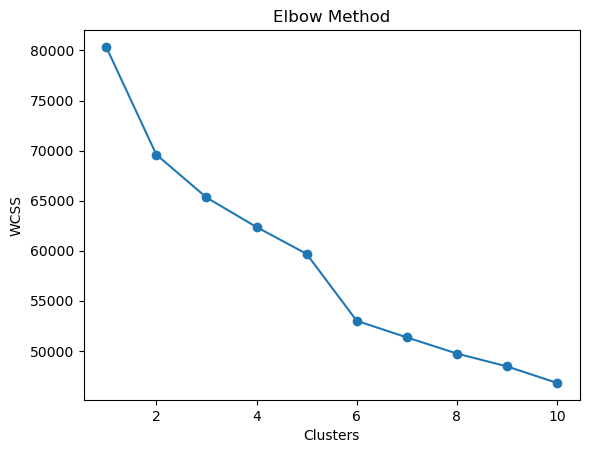

In [57]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [58]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(scaled_data)

In [59]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_data, df['Cluster'])

print(score)

0.09930464661745735


In [60]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

print(cluster_summary)

         satisfaction_score     listing_id  tower_number  unit_number  \
Cluster                                                                 
0                  3.020215  114848.878080     11.475679    29.699937   
1                  3.052419   94872.540323      9.489055    28.106567   
2                  3.054902   94229.206100      9.505882    28.335512   
3                  3.076286  113740.457717     11.371378    30.347132   

         floor_area_sqft     sale_price        Age  
Cluster                                             
0            1541.349886  467589.576507  55.640556  
1             843.162287  252587.263618  55.054147  
2             797.271368  238541.528514  57.675381  
3            1539.125115  469906.779213  56.891189  


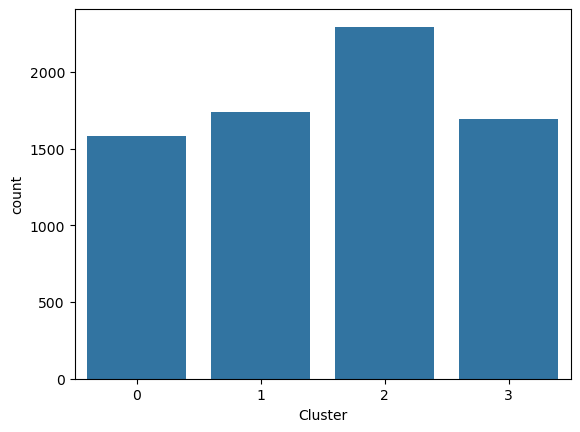

In [61]:
sns.countplot(x='Cluster', data=df)
plt.show()

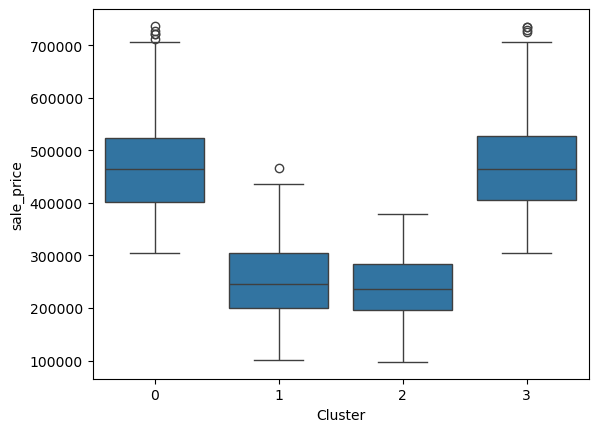

In [62]:
sns.boxplot(x='Cluster', y='sale_price', data=df)
plt.show()

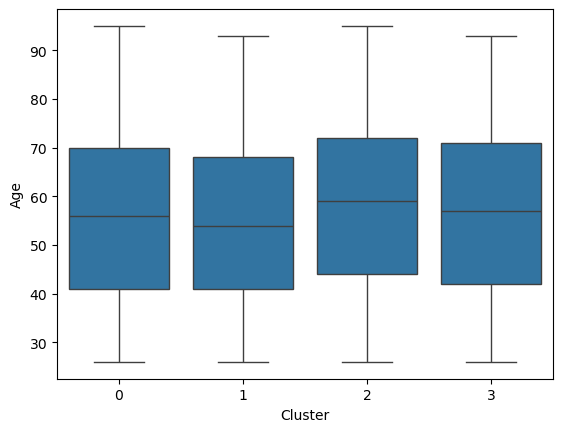

In [63]:
sns.boxplot(x='Cluster', y='Age', data=df)
plt.show()

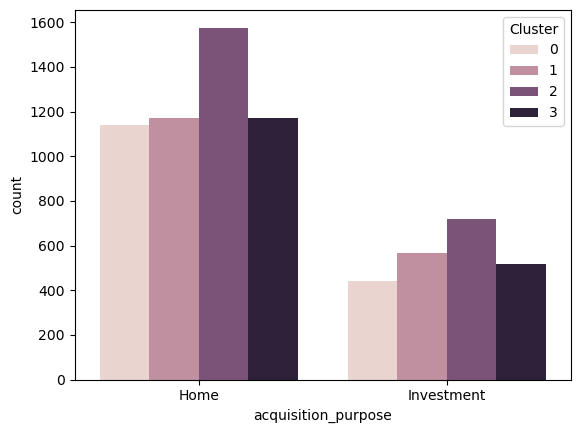

In [68]:
sns.countplot(
    x='acquisition_purpose',
    hue='Cluster',
    data=df
)

plt.show()